In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Project 3 ready!")

Project 3 ready!


In [2]:
import os

os.listdir()

['.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.ms-ad',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Customer_Churn_Analysis.ipynb',
 'customer_churn_dataset-testing-master.csv',
 'customer_segmentation.xlsx',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{69bec8d5-b6fb-11f0-ab84-8255350439bb}.TM.blf',
 'NTUSER.DAT{69bec8d5-b6fb-11f0-ab84-8255350439bb}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{69bec8d5-b6fb-11f0-ab84-8255350439bb}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'README.md',
 'Recent',
 'requirements.txt',
 'Retail_Customer_Segmentation.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Sti_Trace.log',
 'Templates',
 'Untitled.ipynb',
 'untitled.txt',
 'untitled1.txt']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("customer_segmentation.xlsx")

In [3]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   index        541909 non-null  int64         
 1   InvoiceNo    541909 non-null  object        
 2   StockCode    541909 non-null  object        
 3   Description  540455 non-null  object        
 4   Quantity     541909 non-null  int64         
 5   InvoiceDate  541909 non-null  datetime64[us]
 6   UnitPrice    541909 non-null  float64       
 7   CustomerID   406829 non-null  float64       
 8   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), object(3), str(1)
memory usage: 37.2+ MB


In [5]:
df.shape

(541909, 9)

In [6]:
df.isnull().sum()

index               0
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,index,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909,541909.000000,406829.000000
mean,270954.000000,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,0.000000,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,135477.000000,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,270954.000000,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,406431.000000,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,541908.000000,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,156435.797851,218.081158,NaN,96.759853,1713.600303


In [8]:
df[df["CustomerID"].isnull()].head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [9]:
df[df["Quantity"] < 0].head(10)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [10]:
clean_df = df.copy()

# Remove rows with missing Customer IDs
clean_df = clean_df.dropna(subset=["CustomerID"])

# Keep only completed purchases
clean_df = clean_df[clean_df["Quantity"] > 0]

# Keep only positive prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

clean_df.shape

(397884, 9)

In [11]:
clean_df["TotalSales"] = clean_df["Quantity"] * clean_df["UnitPrice"]

clean_df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
clean_df["TotalSales"].sum()

np.float64(8911407.904)

In [13]:
print(f"Total Sales: ${clean_df['TotalSales'].sum():,.2f}")

Total Sales: $8,911,407.90


In [14]:
print(f"Total Customers: {clean_df['CustomerID'].nunique():,}")

Total Customers: 4,338


In [15]:
print(f"Countries Served: {clean_df['Country'].nunique()}")

Countries Served: 37


In [16]:
clean_df["Country"].value_counts()

Country
United Kingdom          354321
Germany                   9040
France                    8341
EIRE                      7236
Spain                     2484
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1462
Australia                 1182
Norway                    1071
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


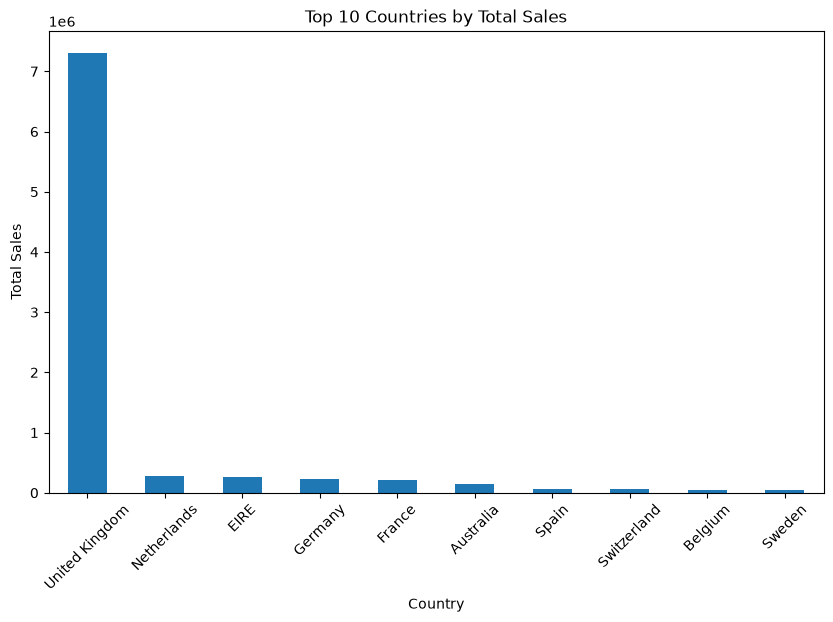

In [17]:
country_sales = (
    clean_df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

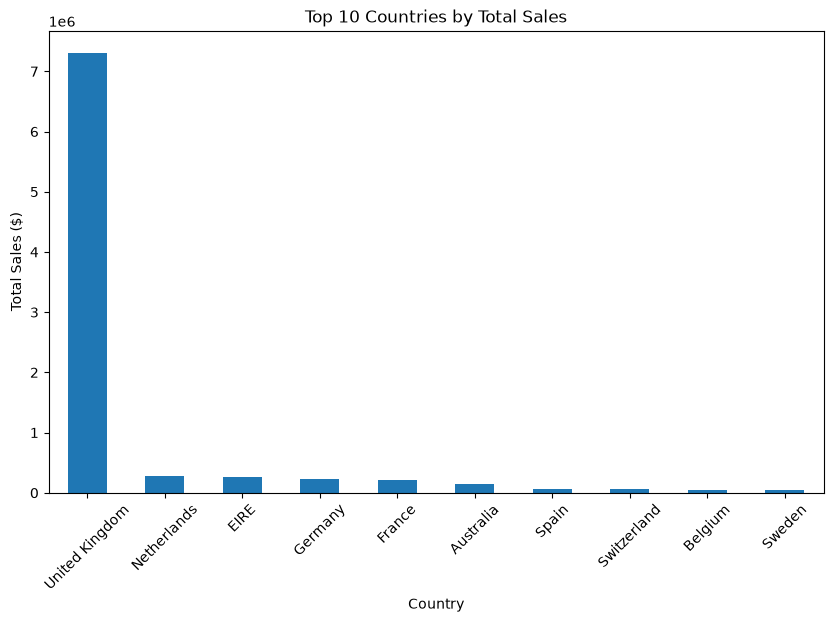

In [18]:
country_sales = (
    clean_df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.show()

In [19]:
top_customers = (
    clean_df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalSales, dtype: float64

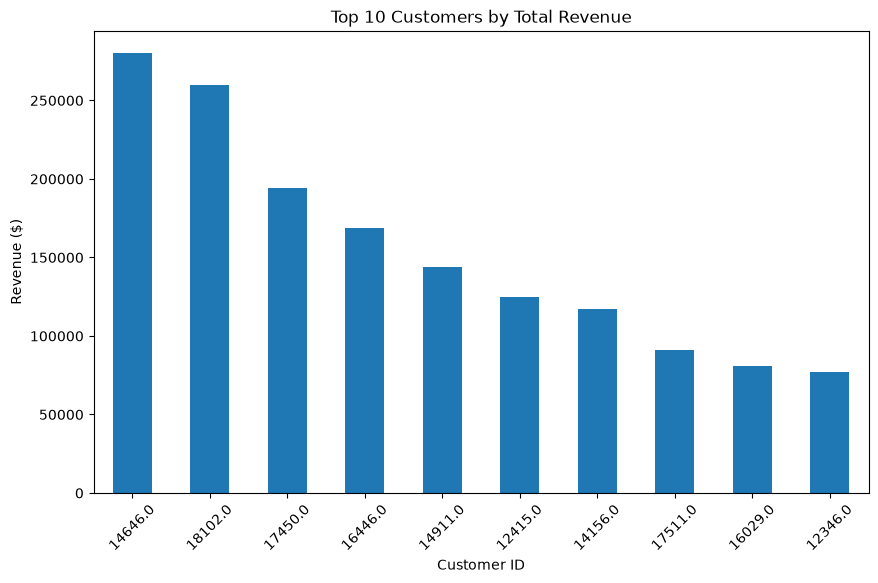

In [20]:
top_customers = (
    clean_df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Total Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()

In [21]:
clean_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [22]:
snapshot_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [23]:
rfm = clean_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalSales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled[:5])

[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


In [25]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

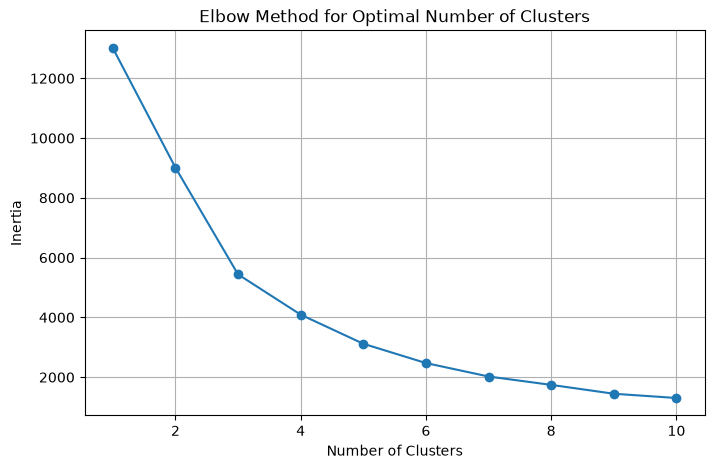

In [26]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [27]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [28]:
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [29]:
rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


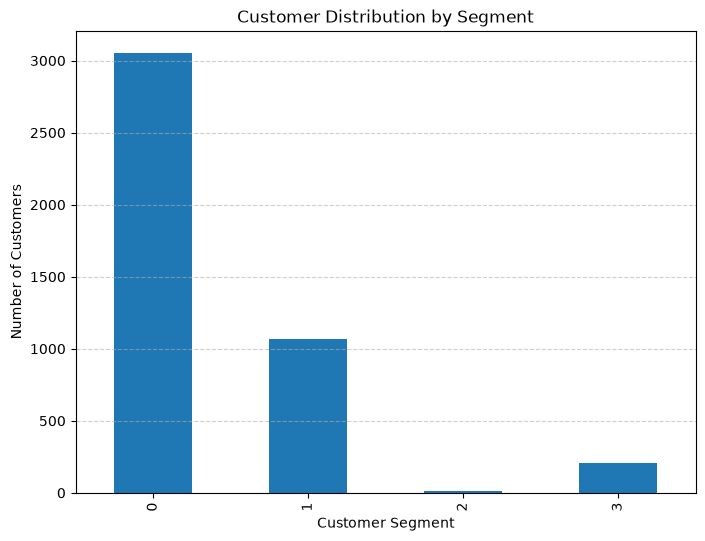

In [30]:
import matplotlib.pyplot as plt

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,6))

cluster_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

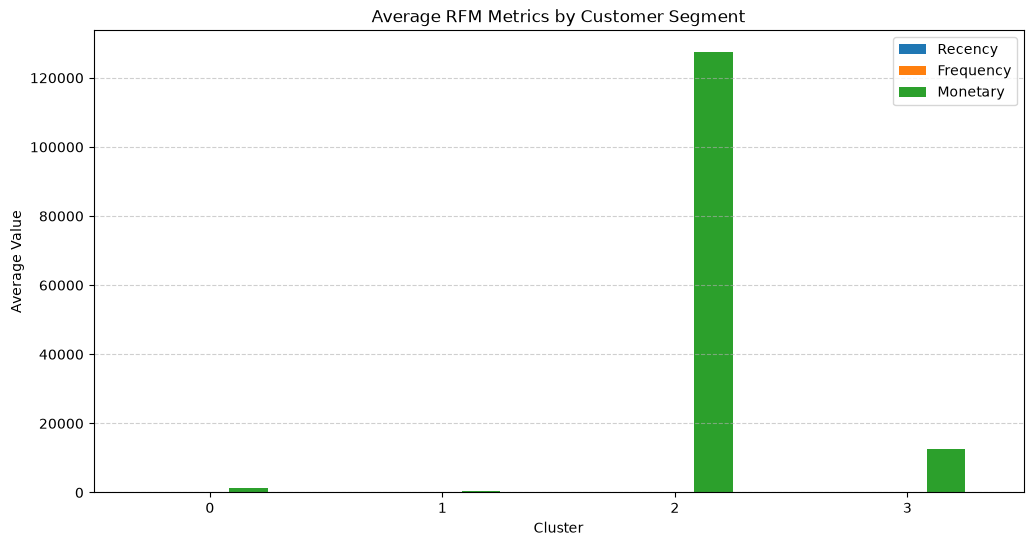

In [31]:
cluster_summary = rfm.groupby("Cluster").mean().round(2)

cluster_summary.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average RFM Metrics by Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [32]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal High-Value Customers"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk Customers


In [34]:
cluster_names = {
    0: "Active Customers",
    1: "At-Risk Customers",
    2: "Elite VIP Customers",
    3: "High-Value Customers"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,High-Value Customers
12347.0,2,7,4310.00,0,Active Customers
12348.0,75,4,1797.24,0,Active Customers
12349.0,19,1,1757.55,0,Active Customers
12350.0,310,1,334.40,1,At-Risk Customers


In [35]:
segment_summary = rfm.groupby("Customer Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

segment_summary

,Recency,Frequency,Monetary
Customer Segment,,,
Active Customers,43.70,3.68,1359.05
At-Risk Customers,248.08,1.55,480.62
Elite VIP Customers,7.38,82.54,127338.31
High-Value Customers,15.50,22.33,12709.09


In [36]:
rfm.to_csv("customer_segments.csv")

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!


In [37]:
clean_df.to_csv("clean_retail_data.csv", index=False)

print("Clean retail dataset saved successfully!")

Clean retail dataset saved successfully!
